# **Генерация синтетического КТ из МРТ**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/iu5git/Data-Science/blob/main/MRI-to-CT_synthesis/MRI-to-CT_Synthesis.ipynb)


__Задача.__  По МРТ-изображению синтезировать соответствующее КТ-изображение, чтобы использовать его для планирования лучевой терапии вместо реального КТ. (Запустить модель с обученными весами. Обучить модель для генерации синтетического КТ. Оценить результат)

__Методы обучения.__ Приведены примеры использования нейронной сети UNetpp5.

__Оценка результатов.__ Нужно оценить качество генерации с помощью метрик PSNR, MAE, SSIM. Результаты визуализировать.

__Данные.__ Две анатомические области: грудная клетка (TH) и брюшная полость (AB)


для началы работы необходимо доустановить библиотеки:
*   monai (!pip install monai)
*   konfai (!pip install konfai==1.5.4)
* SimpleITK (!pip install SimpleITK)



In [ ]:
# # Устанавливаем KonfAI (
# !pip install konfai==1.5.4
# !pip install monai

# !pip install SimpleITK
# !pip install itk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.0/169.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 78.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import (
    LoadImage,
    ScaleIntensity,
    Compose,
    EnsureChannelFirst
)
from monai.networks.utils import one_hot
from monai.visualize import blend_images
import SimpleITK as sitk

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Для работы необходимо скачать бесплатный датасет https://zenodo.org/records/14918214

Скачаем с помощью утилиты wget на Google Disk. Нам понадобятся только области AB и TH. Для работы с ним необходимо поменять названий файлов с нижнего регистра на верхний.

In [ ]:
drive.mount('/content/drive')

!wget -P "/content/drive/MyDrive/" "https://zenodo.org/records/14918214/files/synthRAD2025_Task1_Train.zip?download=1"
!unzip "/content/drive/MyDrive/synthRAD2025_Task1_Train.zip" -d "/content/drive/MyDrive/synthRAD2025_Task1_Train/"

!rm "/content/drive/MyDrive/synthRAD2025_Task1_Train.zip"

In [ ]:
!mkdir -p /content/synthrad_work
%cd /content/synthrad_work

!ln -s /content/drive/MyDrive/synthRAD2025_Task1_Train ./Dataset

Mounted at /content/drive
/content/synthrad_work


Срезы: (91, 367, 465)


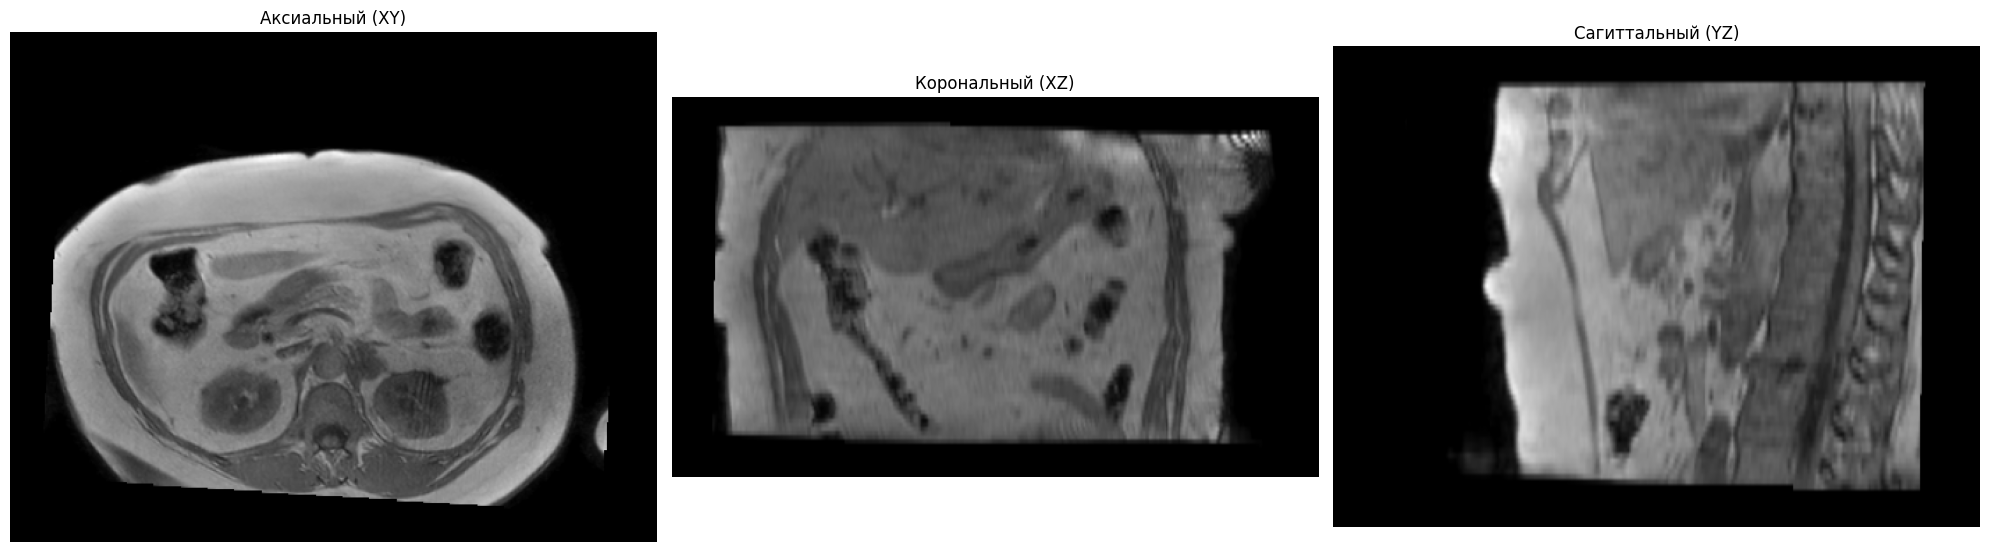

In [ ]:
image = sitk.ReadImage("Dataset/AB/1ABA005/MR.mha")
image_array = sitk.GetArrayFromImage(image)
spacing = image.GetSpacing()

print(f"Срезы: {image_array.shape}")

mid_z = image_array.shape[0] // 2
mid_y = image_array.shape[1] // 2
mid_x = image_array.shape[2] // 2


fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].imshow(image_array[mid_z, :, :], cmap='gray')
axes[0].set_title(f"Аксиальный (XY)")
axes[0].axis('off')


asp_coronal = spacing[2] / spacing[0]
axes[1].imshow(np.flipud(image_array[:, mid_y, :]), cmap='gray', aspect=asp_coronal)
axes[1].set_title(f"Корональный (XZ)")
axes[1].axis('off')

asp_sagittal = spacing[2] / spacing[1]
axes[2].imshow(np.flipud(image_array[:, :, mid_x]), cmap='gray', aspect=asp_sagittal)
axes[2].set_title(f"Сагиттальный (YZ)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Мы визуализировали мрт в трех проекциях. Срезы выбраны по середине объема (вы можете изменить индексы, чтобы просмотреть другие слои)


1.   Аксиальный срез - вид сверху;
2.   Корональный срез - вид спереди;
3.   Саггитальный срез - вид сбоку;


## **Предобработка данных (Трансформации)**
Для того чтобы подготовить медицинские изображения к загрузке в нейронную сеть, к ним обычно применяют трансформации (нормализацию, изменение размера, аугментацию). В качестве примера применим трансформ из специализированной библиотеки MONAI.

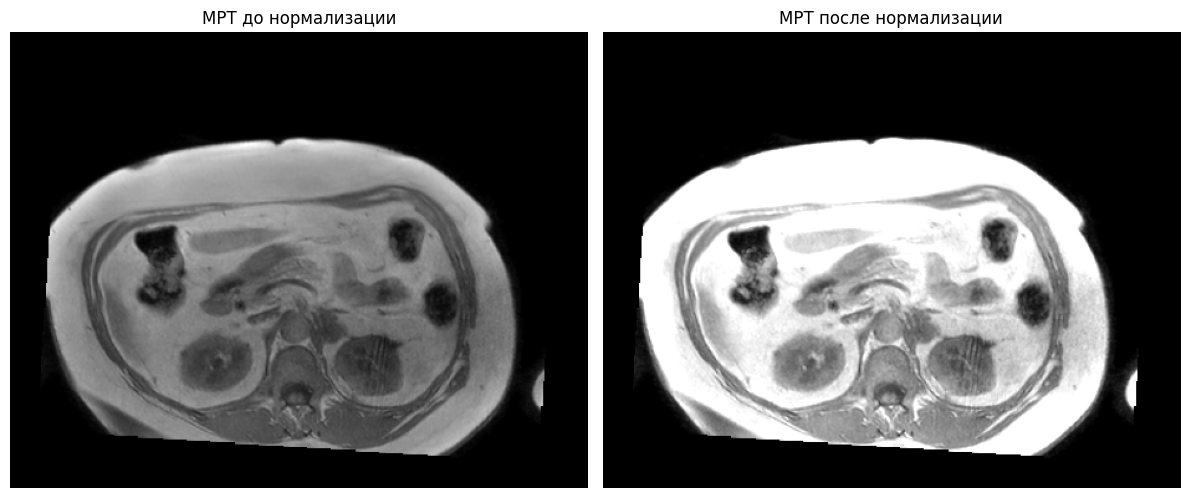

In [ ]:
import torch
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged
)
from monai.data import ITKReader

data_dict = {"image": "Dataset/AB/1ABA005/MR.mha"}


preprocessing = Compose([
    LoadImaged(keys=["image"], reader=ITKReader()),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
])


processed_data = preprocessing(data_dict)
img_tensor = processed_data["image"]


fig, axes = plt.subplots(1, 2, figsize=(12, 6))


mid_slice = img_tensor.shape[1] // 2


axes[0].imshow(image_array[mid_z, :, :], cmap='gray')
axes[0].set_title(f"МРТ до нормализации")
axes[0].axis('off')

mid_z_tensor = img_tensor.shape[3] // 2
slice_2d = img_tensor[0, : , :, mid_z_tensor]

axes[1].imshow(slice_2d.T, cmap='gray')
axes[1].set_title("МРТ после нормализации") # Исправлено: set_title
axes[1].axis('off')


plt.tight_layout()
plt.show()

**Интенсивность** — это числовое значение яркости каждого пикселя медицинского изображения.

В КТ интенсивность имеет абсолютный физический смысл (шкала Хаунсфилда). Одна и та же ткань всегда имеет одинаковые значения на любом аппарате:

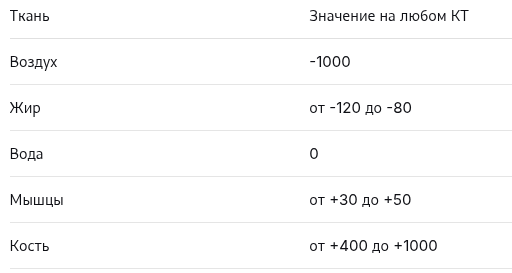

В МРТ такой единой шкалы нет. Значения сильно зависят от типа аппарата, его настроек:
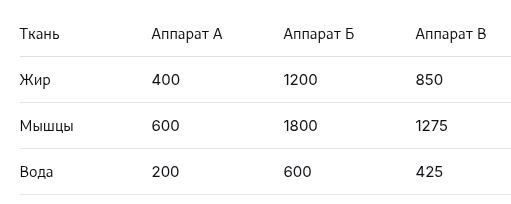

В данном трансформе мы применили нормировку интенсивностей, которая привела все значения к единому диапазону от 0 до 1.

Дополнительное задание: примените другие трансформы к изображениям. Список трансформов можно посмотреть:


*   https://monai.readthedocs.io/en/1.4.0/transforms.html#vanilla-transforms (работает только с vpn)
*   https://github.com/Project-MONAI/MONAI/tree/dev/monai/transforms



## **Использование обученной модели**

Склонируем необходимый репозиторий

In [ ]:
!git clone https://github.com/vboussot/Synthrad2025_Task_1.git

!cp Synthrad2025_Task_1/KonfAI/UNetpp.py .
!cp Synthrad2025_Task_1/KonfAI/UnNormalize.py .

Cloning into 'Synthrad2025_Task_1'...
remote: Enumerating objects: 241, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 241 (delta 129), reused 155 (delta 69), pack-reused 0 (from 0)
Receiving objects: 100% (241/241), 2.94 MiB | 21.08 MiB/s, done.
Resolving deltas: 100% (129/129), done.


Нам необходимо скачать веса предобученной модели с ресурса https://huggingface.co/

Для этого необходимо установить пакет (!pip install huggingface_hub)

In [ ]:
!pip install huggingface_hub

In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="VBoussot/Synthrad2025",
    local_dir=".",
    local_dir_use_symlinks=False,
    allow_patterns=["Task_1/AB-TH/*"],
    )

The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

'/content/synthrad_work'

Для предсказаний нам необходимо скопировать файл Prediction.yml в корень папки synthrad_work

In [ ]:
!cp Task_1/AB-TH/Prediction.yml .

In [ ]:
!pip install -r Synthrad2025_Task_1/requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.3 MB/s eta 0:00:00


В этой работе мы будем использовать KonfAI.

**KonfAI** — это модульный фреймворк для глубокого обучения в медицинской визуализации, построенный вокруг YAML-ориентированных рабочих процессов.

Он позволяет определять полные пайплайны — от загрузки данных до предсказания и оценки — через конфигурацию, а не через скрипты оркестрации.

* Воспроизводимые рабочие процессы с явными
конфигурациями и выходными данными

* Модульные компоненты для наборов данных, преобразований, моделей, функций потерь и метрик

* Разработан для исследований, экспериментов и автоматизированных рабочих процессов (с использованием ИИ-агентов)

In [ ]:
!konfai PREDICTION -y --gpu 0 \
  --models Task_1/AB-TH/CV_0.pt \
           Task_1/AB-TH/CV_1.pt \
           Task_1/AB-TH/CV_2.pt \
           Task_1/AB-TH/CV_3.pt \
           Task_1/AB-TH/CV_4.pt

Prediction : GPU([0]) Memory GPU (14.65G (90.96 %)) | Memory (8.35G (73.10 %)):   2% 89/5666 [09:02<9:15:45,  5.98s/it]
[KonfAI] Manual interruption (Ctrl+C)
Prediction : GPU([0]) Memory GPU (14.65G (90.96 %)) | Memory (8.35G (73.10 %)):   2% 89/5666 [09:08<9:32:26,  6.16s/it]
Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1575, in _shutdown
    def _shutdown():
    
KeyboardInterrupt: 


(93, 489, 489)


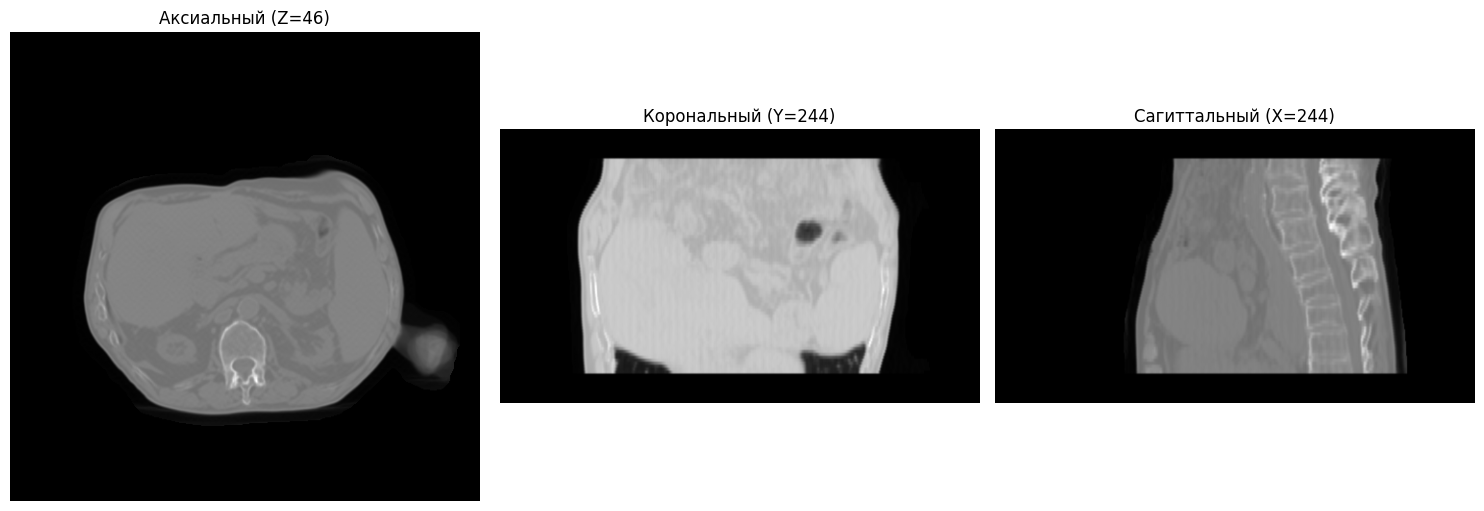

In [ ]:
import matplotlib.pyplot as plt
import SimpleITK as sitk

image = sitk.ReadImage("Predictions/Out/Dataset/1ABB043/sCT.mha")
arr = sitk.GetArrayFromImage(image)
print(arr.shape)
mid = arr.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(arr[mid, :, :], cmap='gray')
axes[0].set_title(f"Аксиальный (Z={mid})")
axes[0].axis('off')

asp_coronal = spacing[2] / spacing[0]
mid = arr.shape[1] // 2

axes[1].imshow(arr[:, mid, :], cmap='gray', aspect=asp_coronal)
axes[1].set_title(f"Корональный (Y={mid})")
axes[1].axis('off')


asp_sagittal = spacing[2] / spacing[0]
mid = arr.shape[2] // 2
axes[2].imshow(arr[:, :, mid], cmap='gray', aspect=asp_sagittal)
axes[2].set_title(f"Сагиттальный (X={mid})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Также сравните визуально с оригинальным КТ

# **Метрики**

Для оценки точности синтезированных КТ-изображений ($sCT$) относительно оригинальных ($CT$) используются следующие метрики:

1. **MAE (Mean Absolute Error)** — средняя абсолютная ошибка:

MAE вычисляет среднюю абсолютную разницу в интенсивностях между пикселями синтезированного и реального КТ. Измеряется в единицах Хаунсфилда (HU). Чем меньше значение MAE, тем точнее модель восстанавливает плотность тканей.

$$ MAE (CT, sCT) = \frac{1}{|B|} \sum_{i \in B} |CT_i - sCT_i| $$

2. **PSNR (Peak Signal-to-Noise Ratio)** — пиковое отношение сигнала к шуму:

PSNR измеряет отношение максимально возможной интенсивности сигнала к мощности шума. Измеряется в децибелах (дБ). Чем выше PSNR, тем выше качество изображения. Значения выше 30 дБ считаются отличными.

$$ PSNR (CT, sCT) = 10 \log_{10} \frac{Q^2}{\frac{1}{|B|} \sum_{i \in B} (CT_i - sCT_i)^2} $$

3. **SSIM (Structural Similarity Index Measure)** — индекс структурного сходства:

SSIM оценивает сходство двух изображений по яркости, контрасту и структуре. Значение SSIM находится в диапазоне от 0 до 1, где 1 означает полную идентичность.

$$ SSIM (x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)} $$


**Где:**
* $B$ — число примеров в выборке (пикселей/вокселей);
* $CT_i$ — значение интенсивности оригинального пикселя;
* $sCT_i$ — значение интенсивности синтезированного пикселя;
* $Q$ — максимально возможная интенсивность сигнала;


In [ ]:
import torch
import SimpleITK as sitk
from monai.metrics import MAEMetric, PSNRMetric, SSIMMetric
from pathlib import Path

case_id = "1ABB078"
gt_ct_path = "/content/synthrad_work/Dataset/AB/1ABB078/CT.mha"
# gt_ct_path = Path("Dataset") / "AB" / case_id / "CT.mha"
# pred_ct_path = Path("Predictions") / "Out" / "Dataset" /case_id / "sCT.mha"
pred_ct_path = "/content/synthrad_work/KonfAI/examples/Synthesis/Predictions/TRAIN_01/Dataset/1ABB078/sCT.mha"
def calculate_all_monai_metrics(gt_path, pred_path):

    gt_array = sitk.GetArrayFromImage(sitk.ReadImage(str(gt_path)))
    pred_array = sitk.GetArrayFromImage(sitk.ReadImage(str(pred_path)))


    gt_tensor = torch.from_numpy(gt_array).float().unsqueeze(0).unsqueeze(0)
    pred_tensor = torch.from_numpy(pred_array).float().unsqueeze(0).unsqueeze(0)


    max_v = (gt_tensor.max() - gt_tensor.min()).item()


    mae_metric = MAEMetric(reduction="mean")
    psnr_metric = PSNRMetric(max_val=max_v, reduction="mean")
    ssim_metric = SSIMMetric(spatial_dims=3, data_range=max_v)

    mae_res = mae_metric(y_pred=pred_tensor, y=gt_tensor)
    psnr_res = psnr_metric(y_pred=pred_tensor, y=gt_tensor)
    ssim_res = ssim_metric(y_pred=pred_tensor, y=gt_tensor)


    return mae_res.item(), psnr_res.item(), ssim_res.item()

try:
    mae, psnr_val, ssim_val = calculate_all_monai_metrics(gt_ct_path, pred_ct_path)

    print(f"MAE (MAEMetric):   {mae:.2f} HU")
    print(f"PSNR (PSNRMetric): {psnr_val:.2f} dB")
    print(f"SSIM (SSIMMetric): {ssim_val:.4f}")


except Exception as e:
    print(f"Ошибка при расчете: {e}")

MAE (MAEMetric):   719.81 HU
PSNR (PSNRMetric): 18.51 dB
SSIM (SSIMMetric): 0.5522


# Обучение модели с нуля

In [ ]:
!git clone https://github.com/vboussot/KonfAI.git

Cloning into 'KonfAI'...
remote: Enumerating objects: 1288, done.
remote: Counting objects: 100% (458/458), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 1288 (delta 237), reused 382 (delta 201), pack-reused 830 (from 1)
Receiving objects: 100% (1288/1288), 8.80 MiB | 4.33 MiB/s, done.
Resolving deltas: 100% (747/747), done.


В рассматриваемом примере представлены два варианта синтеза:

1. **Базовый рабочий процесс** — настройки в файле `Config.yml`.
2. **Расширенный GAN-рабочий процесс** — настройки в файле `Config_GAN.yml`.

Оба варианта используют общие файлы:
- `Prediction.yml`
- `Evaluation.yml`
- `Model.py`

Для первого запуска следует использовать базовый вариант, как наиболее простой.

GAN-вариант демонстрирует:
- 2D / 2.5D генератор;
- 3D дискриминатор;
- семантику накопления патчей `;accu;`, применяемую в KonfAI.

In [ ]:
import os
import subprocess
import sys

REPO_PATH = Path("/content/synthrad_work/KonfAI")

if os.path.exists(REPO_PATH):

    if os.path.exists(f"{REPO_PATH}/setup.py") or os.path.exists(f"{REPO_PATH}/pyproject.toml"):
        subprocess.run([sys.executable, "-m", "pip", "install", "-e", REPO_PATH], check=True)
        print("Установка зависисмостей")
    else:
        print("Нет setup.py или pyproject.toml")
else:
    print(f"Папка {REPO_PATH} не найдена")

Установка зависисмостей


In [ ]:
import shutil
import random
from pathlib import Path

EXAMPLE_DIR = REPO_PATH / "examples" / "Synthesis"
DATASET_DIR = EXAMPLE_DIR / "Dataset"

SOURCE_AB = Path("/content/synthrad_work/Dataset/AB")

all_folders = [f for f in SOURCE_AB.iterdir() if f.is_dir()]

print(f"Папок в AB: {len(all_folders)}")

selected = random.sample(all_folders, 2)
print(f"Выбраны: {[f.name for f in selected]}")

for folder in selected:
    shutil.copytree(folder, DATASET_DIR / folder.name, dirs_exist_ok=True)


Папок в AB: 175
Выбраны: ['1ABB170', '1ABB155']


* Добавьте также по области TH в датасет
*   Перед обучением поменяйте в файле Config.yml batch = 4, epochs = 5 (можете на свое усмотрение)


In [ ]:
%cd /content/synthrad_work/KonfAI/examples/Synthesis
!konfai TRAIN -y --gpu 0 --config Config.yml

Streaming output truncated to the last 5000 lines.
Training : Loss (UNetpp5(0.001000) : MAE(1.00) : 0.040157 IMPACTSynth(1.00) : 0.557047 L1Loss(1.00) : 0.040157 MAE(1.00) : 0.051216) GPU([0]) Memory GPU (3.60G (22.34 %)) | Memory (6.72G (56.50 %)):  35% 1239/3512 [06:31<11:24,  3.32it/s]
Training : Loss (UNetpp5(0.001000) : MAE(1.00) : 0.040157 IMPACTSynth(1.00) : 0.557047 L1Loss(1.00) : 0.040157 MAE(1.00) : 0.051216) GPU([0]) Memory GPU (3.60G (22.34 %)) | Memory (6.72G (56.50 %)):  35% 1240/3512 [06:31<11:20,  3.34it/s]cuda:0

Training : Loss (UNetpp5(0.001000) : MAE(1.00) : 0.047415 IMPACTSynth(1.00) : 0.445265 L1Loss(1.00) : 0.047415 MAE(1.00) : nan) GPU([0]) Memory GPU (3.60G (22.34 %)) | Memory (6.72G (56.50 %)):  35% 1240/3512 [06:31<11:20,  3.34it/s]     
Training : Loss (UNetpp5(0.001000) : MAE(1.00) : 0.047415 IMPACTSynth(1.00) : 0.445265 L1Loss(1.00) : 0.047415 MAE(1.00) : nan) GPU([0]) Memory GPU (3.60G (22.34 %)) | Memory (6.72G (56.50 %)):  35% 1241/3512 [06:31<11:32,  3

После завершения обучения результаты автоматически сохраняются в следующей папке:

- `Checkpoints/TRAIN_01/` or `Checkpoints/TRAIN_GAN_01/`
- `Statistics/TRAIN_01/` or `Statistics/TRAIN_GAN_01/`

Используем модель для наших предсказаний. стоит заменить содержимое файла Prediction.yml на другое. Необходимый файл лежит в папке на github

In [ ]:
%cd /content/synthrad_work/KonfAI/examples/Synthesis

/content/synthrad_work/KonfAI/examples/Synthesis


In [ ]:
!konfai PREDICTION -y --gpu 0 --config Prediction.yml --models Checkpoints/TRAIN_01/2026_05_04_20_38_33.pt

Prediction : GPU([0]) Memory GPU (1.65G (10.26 %)) | Memory (5.37G (46.50 %)): 100% 1317/1317 [01:15<00:00, 17.51it/s]


После завершения обучения результаты автоматически сохраняются в следующей папке:

- `Predictions/TRAIN_01/` or `Predictions/TRAIN_GAN_01/`


Посмотрите также визуально на синтетическое КТ и оцените качество по метрикам. Сравните с эталонной моделью.

По собственному желанию можно попробовать также с другой областью данных - HN (голова и шея)
